### 서비스 니즈 파악:


IT아웃소싱 시장에서 고객들의 외주 의뢰 패턴 및 선호도를 분석하여, 차별화된 서비스 제공방안을 모색합니다. 

현황: 


동종업계의 공격적인 마케팅


IT전문가들 이탈


서비스간 적정가격 책정의 부재로 고객불만 증가


아웃소싱 거래가 어플리케이션 외의 개인적인 연락으로 전환되어 거래 지속성 감소. 


이로 인한 거래 성사율 정체 및 전문가 이탈 심화되면 수수료 기반 매출유지 어려울 것으로 우려됨.


거래 성사율 개선 및 적정 수수료 책정방안 도출 시급.

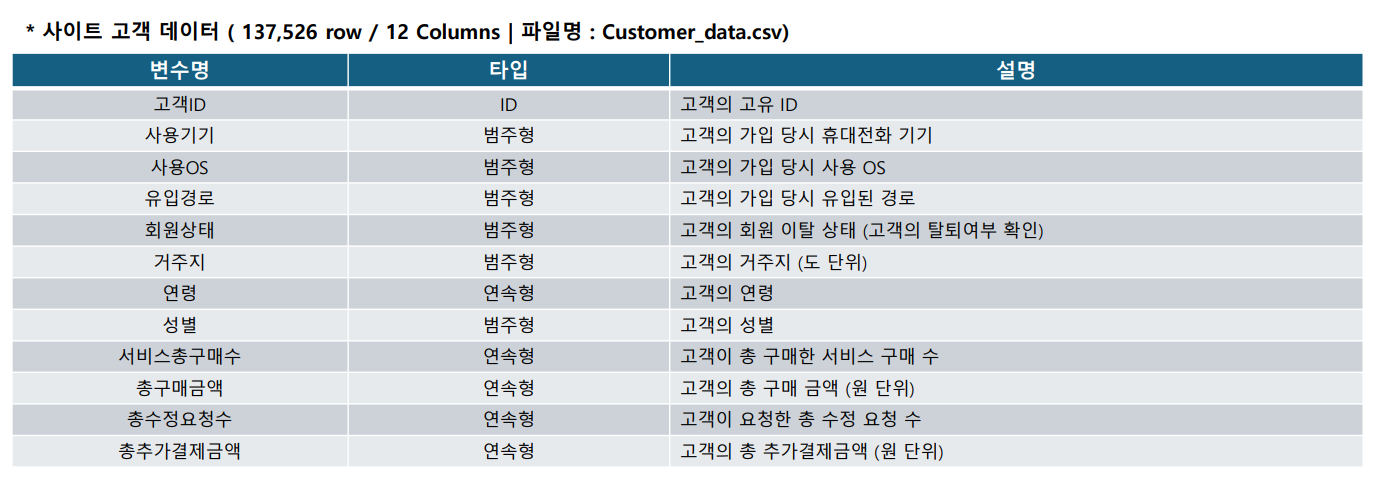

사이트 고객 데이터를 통해 외주의뢰패턴은 사용기기, 유입경로를 통해 파악 가능
선호도는 별도 자료 활용해야 함. 
최종 정답지를 이탈상태 예측으로 할 경우, 사이트 고객 데이터로는 불충분. 사용기기나 유입경로를 통해 광고매체에 따른 집중비용 투하 필요 매체 선별은 가능

In [44]:
import pandas as pd

df = pd.read_csv("Customer_data.csv")
df.head(3)

,고객ID,사용기기,사용OS,유입경로,회원상태,거주지,연령,성별,서비스총구매수,총구매금액,총수정요청수,총추가결제금액
0,1.001010e+09,iPhone,iOS11.4.1,유튜브,정상회원,경기도,25.0,남성,1,44500.0,0.0,14500
1,1.001010e+10,SM-N935S,Android7.0,검색광고,정상회원,경기도,26.0,NaN,1,44500.0,0.0,14500
2,1.001010e+11,iPhone,iOS12.0,네이버블로그,정상회원,경기도,23.0,남성,1,34500.0,0.0,14500


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137526 entries, 0 to 137525
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   고객ID     137526 non-null  float64
 1   사용기기     137526 non-null  object 
 2   사용OS     137526 non-null  object 
 3   유입경로     135920 non-null  object 
 4   회원상태     137526 non-null  object 
 5   거주지      137526 non-null  object 
 6   연령       135722 non-null  float64
 7   성별       127267 non-null  object 
 8   서비스총구매수  137526 non-null  int64  
 9   총구매금액    137521 non-null  float64
 10  총수정요청수   137526 non-null  float64
 11  총추가결제금액  137526 non-null  int64  
dtypes: float64(4), int64(2), object(6)
memory usage: 12.6+ MB


In [46]:
df['사용기기'].unique()

array(['iPhone', 'SM-N935S', 'SM-G955N', 'SM-G930S', 'SM-G960N',
       'SM-A530N', 'LG-F800S', 'SM-T820', 'SM-G965N', 'SM-J111F',
       'SM-N910S', 'SM-N915L', 'SM-G930K', 'Mi A1', 'SM-A810S',
       'SM-G935K', 'SM-G935S', 'SM-N916K', 'SM-N920K', 'SM-A520S',
       'LM-G710N', 'SM-J530L', 'SM-A720S', 'SM-N950N', 'SM-N920S',
       'SM-G950N', 'LGM-X600L', 'SM-P580', 'SM-J730K', 'SM-N960N',
       'LGM-G600K', 'SM-N920L', 'LGM-V300K', 'LG-F700K', 'SM-N916S',
       'LG-F470K', 'SM-G920K', 'SM-G610S', 'LGM-G600L', 'SM-A600N',
       'LG-F800K', 'LG-F600L', 'Redmi Note 5', 'Mi A2', 'LGM-G600S',
       'SM-J510S', 'LG-F320K', 'SM-N900K', 'LGM-V300S', 'SM-N910L',
       'SM-G955F', 'LGM-X401S', 'SHV-E330S', 'SM-T536', 'SM-G925K',
       'SM-A700L', 'SM-J510K', 'SM-J727S', 'LG-F500L', 'SM-A510S',
       'SM-N935K', 'SM-G610L', 'SM-N916L', 'SM-G900S', 'LG-F700L',
       'SM-N935L', 'SM-G950F', 'LGM-X800L', 'LG-F800L', 'SM-A520K',
       'SM-J500N0', 'LG-F700S', 'SM-A800S', 'SM-G935L', 'T-1

In [47]:
df['사용OS'].unique()

array(['iOS11.4.1', 'Android7.0', 'iOS12.0', 'Android8.0.0',
       'Android7.1.1', 'Android5.1.1', 'Android6.0.1', 'Android8.1.0',
       'iOS11.3.1', 'iOS11.4', 'iOS11.3', 'iOS10.0.1', 'iOS12.1',
       'Android4.4.2', 'Android6.0', 'Android5.0', 'iOS11.2.6',
       'iOS11.2.2', 'iOS10.3.2', 'Android5.0.2', 'iOS11.0', 'iOS11.0.3',
       'iOS11.2', 'iOS10.3.3', 'iOS11.1.2', 'iOS10.2.1', 'iOS10.0.2',
       'Android5.0.1', 'iOS10.1.1', 'iOS11.2.5', 'iOS11.2.1', 'iOS11.1.1',
       'Android7.1.2', 'Android4.4.4', 'iOS10.0.3', 'iOS11.0.2',
       'iOS10.1', 'iOS10.3.1', 'Android9', 'iOS10.2', 'iOS11.0.1',
       'iOS11.1', 'iOS10.3', 'Android5.1', 'Android4.1.2'], dtype=object)

In [48]:
df['유입경로'].unique()

array(['유튜브', '검색광고', '네이버블로그', '인스타그램', '직접검색', '네이버카페', '구글광고', '페이스북',
       '다음카페', '뉴스광고', nan], dtype=object)

In [49]:
df['회원상태'].unique()

array(['정상회원', '탈퇴', '탈퇴처리중'], dtype=object)

In [50]:
df['회원상태'].value_counts()

회원상태
정상회원     132505
탈퇴         4803
탈퇴처리중       218
Name: count, dtype: int64

In [51]:
null_counts = df.isnull().sum()
print(null_counts)

고객ID           0
사용기기           0
사용OS           0
유입경로        1606
회원상태           0
거주지            0
연령          1804
성별         10259
서비스총구매수        0
총구매금액          5
총수정요청수         0
총추가결제금액        0
dtype: int64


In [52]:
# Split using both "-" and space as delimiters
split_cols = df['사용기기'].str.split(r'[-\s]', expand=True)

df['사용기기'] = split_cols[0]

In [53]:
df.head(3)

,고객ID,사용기기,사용OS,유입경로,회원상태,거주지,연령,성별,서비스총구매수,총구매금액,총수정요청수,총추가결제금액
0,1.001010e+09,iPhone,iOS11.4.1,유튜브,정상회원,경기도,25.0,남성,1,44500.0,0.0,14500
1,1.001010e+10,SM,Android7.0,검색광고,정상회원,경기도,26.0,NaN,1,44500.0,0.0,14500
2,1.001010e+11,iPhone,iOS12.0,네이버블로그,정상회원,경기도,23.0,남성,1,34500.0,0.0,14500


In [54]:
df.drop('고객ID', axis=1, inplace=True)
df.head(3)

,사용기기,사용OS,유입경로,회원상태,거주지,연령,성별,서비스총구매수,총구매금액,총수정요청수,총추가결제금액
0,iPhone,iOS11.4.1,유튜브,정상회원,경기도,25.0,남성,1,44500.0,0.0,14500
1,SM,Android7.0,검색광고,정상회원,경기도,26.0,NaN,1,44500.0,0.0,14500
2,iPhone,iOS12.0,네이버블로그,정상회원,경기도,23.0,남성,1,34500.0,0.0,14500


In [55]:
df.columns

Index(['사용기기', '사용OS', '유입경로', '회원상태', '거주지', '연령', '성별', '서비스총구매수', '총구매금액',
       '총수정요청수', '총추가결제금액'],
      dtype='object')

In [56]:
df['회원상태'] = df['회원상태'].replace({'탈퇴처리중': '탈퇴'})
df['회원상태'].unique()

array(['정상회원', '탈퇴'], dtype=object)

In [57]:
# pip install xgboost

In [58]:
from sklearn.preprocessing import LabelEncoder

# y = df['회원상태']
le = LabelEncoder()
df['회원상태'] = le.fit_transform(df['회원상태'])  # '정상회원' → 1, '탈퇴' → 0 또는 반대

# 확인: 어떤 값이 어떤 숫자로 매핑됐는지
print(dict(zip(le.classes_, le.transform(le.classes_))))


{'정상회원': 0, '탈퇴': 1}


In [59]:
df['회원상태'].unique()

array([0, 1])

In [60]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Step 1: Assume df is your DataFrame
# Target

y = df['회원상태']
X = df.drop('회원상태', axis=1)

# Step 2: Convert object-type columns to category dtype (for categorical support)
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Step 4: Train XGBoost
model = XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    use_label_encoder=False,
    eval_metric='mlogloss'  # suitable for classification
)
model.fit(X_train, y_train)

# Step 5: Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [05:40:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.96      1.00      0.98     26502
           1       0.00      0.00      0.00      1004

    accuracy                           0.96     27506
   macro avg       0.48      0.50      0.49     27506
weighted avg       0.93      0.96      0.95     27506



In [61]:
X.columns

Index(['사용기기', '사용OS', '유입경로', '거주지', '연령', '성별', '서비스총구매수', '총구매금액', '총수정요청수',
       '총추가결제금액'],
      dtype='object')

In [62]:
X.columns = [
    'DeviceType',
    'OS',
    'ReferralSource',
    'Region',
    'Age',
    'Gender',
    'TotalServicePurchases',
    'TotalPurchaseAmount',
    'TotalModificationRequests',
    'TotalAdditionalPaymentAmount'
]


In [63]:
from IPython.display import display, HTML

display(HTML('''
<style>
    div.output_area {
        max-width: 100%;
        max-height: 1000px;
    }
</style>
'''))


<Figure size 60000x40000 with 0 Axes>

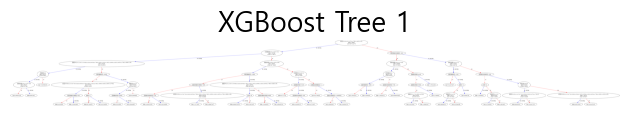

In [64]:
from xgboost import plot_tree
import matplotlib.pyplot as plt

# Choose the tree index you want to plot
tree_index = 1  # change to 1, 2, etc. for other trees

# Set figure size
plt.figure(figsize=(300, 200), dpi=200)

# Plot the tree
plot_tree(model, tree_idx=tree_index, filled=True)

# Show the plot (optional)
plt.title(f"XGBoost Tree {tree_index}", fontsize=20)
plt.tight_layout()
plt.savefig("xgboost_tree.svg", bbox_inches='tight') 
plt.savefig("고객분석.png")
plt.show()
plt.close()


In [65]:
import xgboost as xgb
from IPython.display import SVG
from graphviz import Source

# tree_index 설정
tree_index = 0

# Graphviz 객체 생성
dot = xgb.to_graphviz(model, num_trees=tree_index, rankdir='LR')  # 좌우로 정렬

# .svg 파일로 렌더링
dot.render("xgboost_tree", format='svg', cleanup=False)

# Jupyter에서 SVG로 표시
SVG(filename="xgboost_tree.svg")
plt.savefig("고객분석.png")

C:\Users\User\anaconda3\Lib\site-packages\xgboost\plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 640x480 with 0 Axes>

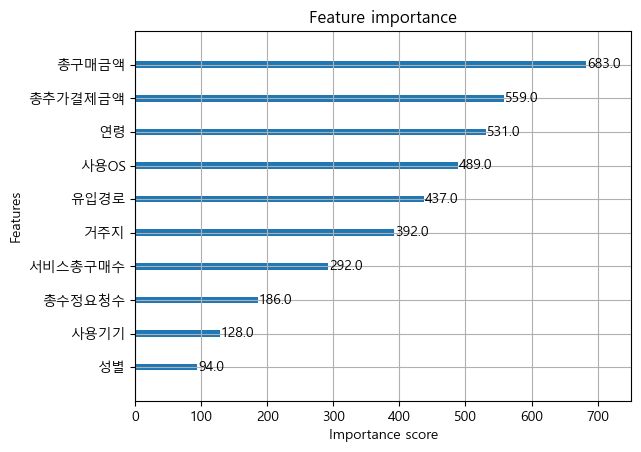

In [66]:
# It’s based on frequency or gain.
# It doesn’t explain the direction (e.g., higher age → more likely active?).

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic' 
xgb.plot_importance(model)
plt.savefig("고객분석_feature_importance.png")
plt.show()

In [67]:
# !pip install shap

C:\Users\User\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  pl.tight_layout()
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


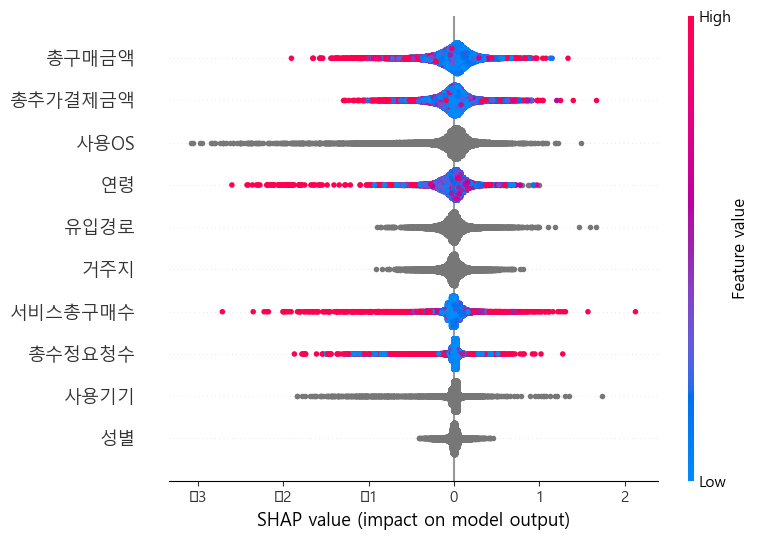

In [68]:
# Which features increase or decrease the probability of each class.
# Global and individual instance explanations.
# Visual plots to show feature effects clearly.

import shap

# Initialize SHAP explainer
explainer = shap.Explainer(model)

# Calculate SHAP values for a subset
shap_values = explainer(X_test)

# Summary plot: which features impact prediction and how
shap.summary_plot(shap_values, X_test)

* 영향력이 큰 순서대로 변수 제시
* 빨간색은 해당 변수의 값이 높고, 파란색은 값이 낮은 경우이며, 회색은 범주형 변수를 의미
* 정상회원:0, 탈퇴:1로서 분류하고자 하는 타겟을 1로 지정
* 총구매금액은 금액이 높을 수록 왼쪽으로 치우쳐 정상회원으로 분류. 즉 많이 구매한 고객은 탈퇴가능성 낮음
* 추가결제금액도 동일하여 추가 결제가 많은 고객이 정상회원으로 분류. 고객 충성도 지표
* 사용os의 경우 특정 값들이 정상회원으로 분류되는데 기여도가 높은 것으로 보이나 해당 값들을 알 수 없으므로 범주형 변수를 위한 별도의 분석이 필요
* 나이의 경우 구매금액이 낮은 고객들은 파란색으로 표시되며 오른쪽에 위치하여 탈퇴회원으로 예측
* 유입경로는 약간 오른쪽으로 치우친 샘플이 있어 특정 유입경로의 경우 탈퇴와 관련있을 가능성 있음.
* 거주지, 사용기기, 성별은 유의미한 결론을 내기 부적합
* 서비스총구매수는 구매수가 높을수록 음수에 치우처서 정상회원일 확률 높음
* 총수정요청수는 수정 요청이 많을수록 오른쪽으로 치우쳐서 탈퇴가능성 높음
* 수치형 변수에 대한 결론: 분석 전에도 구매금액, 추가결제금액, 서비스총구매수는 높을수록 정상회원으로 분류될 것으로 예상되므로 유의미한 분석결과를 제공하지 않으나, 저연령고객과 수정요청이 빈번한 고객의 경우는 탈퇴를 막기위한 별도의 방안이 필요하다는 사실을 알 수 있음.

In [69]:
# 범주형 변수 중 사용OS, 유입경로, 사용기기에 대한 추가적인 분석
# 사용OS는 사용기기를 따라가므로 상관관계가 높은 변수로 삭제도 고려하였으나, 
# 예상치 못한 인사이트 발견을 위해 추가적인 분석 실시

# 레이블 인코딩 후 SHAP 값과 결합
X_encoded = X_test.copy()
label_encoders = {}

# 범주형 변수 레이블 인코딩
for col in df[['사용OS', '유입경로', '사용기기']]:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_test[col])
    label_encoders[col] = le

# SHAP 값 + 인코딩된 피처 결합
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
for col in df[['사용OS', '유입경로', '사용기기']]:
    shap_df[col + '_value'] = X_encoded[col]

# 각 범주형 변수에 대해 평균 SHAP 값 계산
summary_tables = {}
for col in df[['사용OS', '유입경로', '사용기기']]:
    grouped = shap_df.groupby(col + '_value')[col].mean()
    decoded = grouped.rename(index=dict(enumerate(label_encoders[col].classes_)))
    summary_tables[col] = decoded

# 결과를 하나의 데이터프레임으로 결합
summary_df = pd.concat(summary_tables, axis=1)

In [70]:
summary_df['사용OS'].dropna() 
# shap값이 양수만 탈퇴예측에 기여
# 절대값이 0.2이상인 경우 강한 기여로 판단하므로 iOS12.1만 유의미한 값.

Android4.4.2    0.073107
Android4.4.4    0.131594
Android5.0      0.002194
Android5.0.1   -0.136930
Android5.0.2   -0.006310
Android5.1.1   -0.042368
Android6.0      0.090727
Android6.0.1   -0.024720
Android7.0     -0.018890
Android7.1.1   -0.051662
Android7.1.2    0.070031
Android8.0.0   -0.024385
Android8.1.0   -0.009939
Android9       -0.096601
iOS10.0.1       0.014406
iOS10.0.2      -0.174424
iOS10.0.3      -0.047273
iOS10.1         0.030499
iOS10.1.1       0.095141
iOS10.2        -0.148235
iOS10.2.1       0.038218
iOS10.3.1       0.012973
iOS10.3.2      -0.175525
iOS10.3.3       0.008314
iOS11.0.2       0.020953
iOS11.0.3       0.026684
iOS11.1.1      -0.095354
iOS11.1.2      -0.011593
iOS11.2         0.019175
iOS11.2.1      -0.011536
iOS11.2.5      -0.147580
iOS11.2.6      -0.034127
iOS11.3         0.010109
iOS11.3.1      -0.154475
iOS11.4        -0.041774
iOS11.4.1      -0.038363
iOS12.0        -0.031821
iOS12.1        -0.233246
Name: 사용OS, dtype: float32

* iOS12.1이 다른 OS와 두드러지는 차이점을 조사하였으나, 특이사항 없음.
| 항목                               | iOS 12.1의 특징                    | 다른 OS(iOS 12, Android 등)와의 차이점                  |
| -------------------------------- | ------------------------------- | ----------------------------------------------- |
| 📞 **그룹 FaceTime**               | 최대 32명까지 영상 통화 지원               | Android에는 기본 제공 영상회의 앱 없음 (Google Meet 등 별도 설치) |
| 📸 **심도 조절 (Depth Control)**     | 사진 촬영 후 배경 흐림 정도 조절 가능          | 당시 Android에는 일부 고급 기종만 부분 지원                    |
| ❤️ **듀얼 SIM 지원**                 | eSIM + nano-SIM (특정 iPhone 모델만) | Android는 다수 모델에서 물리적 듀얼 SIM 지원                  |
| 🧑🏽‍🤝‍🧑🏻 **70개 이상의 새로운 이모지** | 다양성과 포용성 강조한 이모지 추가             | Android도 이모지 추가 중이었지만 시기적 차이 존재                 |
| 📶 **VoLTE 이중 SIM 동시 지원**        | 일부 국가 및 통신사에 한정해 VoLTE 듀얼 활성화   | Android는 이미 일부 기기에서 지원                          |
| 🐛 **버그 수정 및 성능 향상**             | 특히 iPhone XS, XR 사용자 대상 안정성 향상  | Android는 제조사/기종별로 성능 개선 시기 불규칙                  |


In [71]:
summary_df['사용기기'].dropna() #유의미한 값 없음. 

BBB100    0.006062
BND       0.000604
EVA       0.009521
F5122    -0.006518
G8141    -0.039853
G8441     0.011534
GT        0.005213
HT50      0.008904
HUAWEI   -0.065174
IM        0.018890
LG        0.001348
LGM      -0.006567
LM       -0.004914
Mi       -0.004831
Pixel     0.005960
Redmi     0.069364
SC        0.006306
SHV      -0.002890
SM       -0.005550
T        -0.013586
TG        0.016755
VKY       0.005115
WAS      -0.001761
iPad     -0.004624
iPhone   -0.003726
Name: 사용기기, dtype: float32

In [72]:
summary_df['유입경로'].dropna() 

검색광고     -0.017107
구글광고     -0.014643
네이버블로그   -0.012105
네이버카페    -0.003631
뉴스광고     -0.038113
다음카페     -0.032239
유튜브      -0.015144
인스타그램    -0.025847
직접검색      0.006187
페이스북      0.001437
NaN      -0.009887
Name: 유입경로, dtype: float32

* SHAP summary plot에서 유입경로의 SHAP값 분포가 일부 오른쪽으로 퍼져보이지만 실제 확인한 결과 모두 작거나 음수인 이유는 summary plot은 각 샘플에 대해 해당 변수가 예측에 얼마나 영향을 주었는지 시각화 한것으로 일부 샘플에서만 유입경로가 탈퇴예측인 양의 방향에 기여한 것으로 전체적으로 평균은 여전히 작거나 음수.
* 범주형 변수에서는 고객들의 외주의뢰 패턴 및 선호도 분석 어려운 상황으로, 수치간의 소소한 차이에 기반하여 마케팅을 펼칠 정당성 부족함
* 특정 유입경로가 아닌 다른 변수와 상호작용해서 특정 조합일 때만 탈퇴쪽으로 영향을 미칠 가능성 있음.

C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [05:40:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


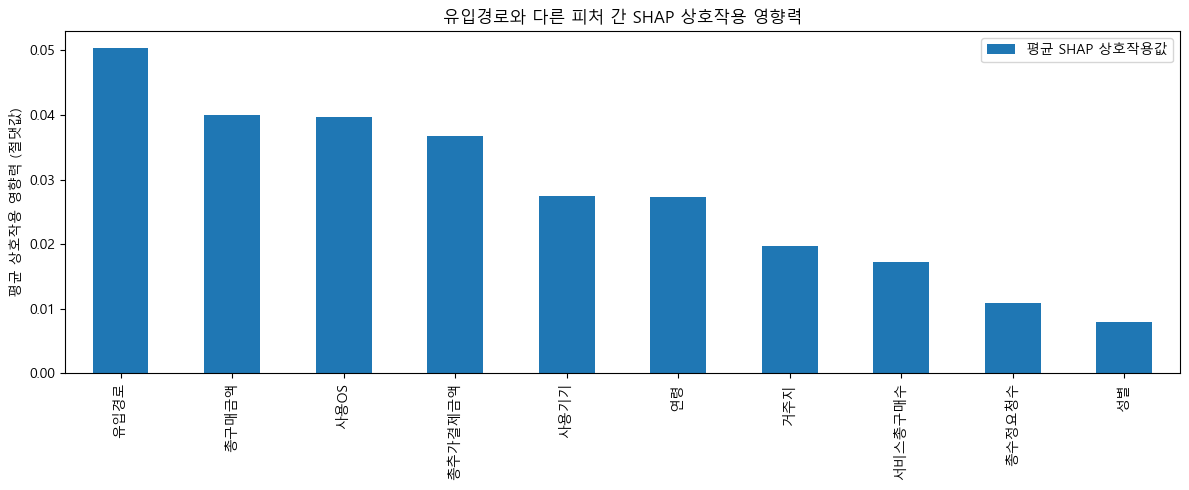

In [73]:
# 단독으로는 탈퇴예측에 기여하지 않지만,
# 다른 변수와 상호작용을 통해 탈퇴예측에 기여하는 경우를 정량적으로 찾고 시각화 하는 방법
# 상화작용 분석은 수치형 데이터에서 안정적으로 작동하여 Label Encoding 후 SHAP분석 추천
# 다만 XGBoost의 경우 enable_categorial=True로 설정하여 범주형 변수 자동처리 가능
# 모델학습은 category 타입 그대로 진행하고 Label Encodng된 데이터로 SHAP 상호작용 분석코드

import pandas as pd
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ----------------------------
# 1. 데이터 준비
# ----------------------------
# 타깃과 피처 분리
y = df['회원상태']
X = df.drop('회원상태', axis=1)

# object 타입 → category 로 변환 (XGBoost 학습용)
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ----------------------------
# 2. 모델 학습
# ----------------------------
model = XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(X_train, y_train)

# ----------------------------
# 3. SHAP 상호작용 분석을 위한 수치화 데이터 생성
# ----------------------------
X_test_encoded = X_test.copy()

# category → int(Label Encoding) (SHAP용)
for col in X_test_encoded.select_dtypes(include='category').columns:
    le = LabelEncoder()
    X_test_encoded[col] = le.fit_transform(X_test_encoded[col])

# ----------------------------
# 4. SHAP 상호작용 값 계산
# ----------------------------
explainer = shap.TreeExplainer(model)
interaction_values = explainer.shap_interaction_values(X_test_encoded)

# ----------------------------
# 5. 유입경로와 다른 모든 변수 간 상호작용 분석
# ----------------------------
feature_names = X_test_encoded.columns.tolist()
target_feature = '유입경로'
target_index = feature_names.index(target_feature)

interaction_summary = {}
for i, feature in enumerate(feature_names):
    interaction_mean = abs(interaction_values[:, i, target_index]).mean()
    interaction_summary[feature] = interaction_mean

# ----------------------------
# 6. 결과 시각화
# ----------------------------
interaction_df = pd.DataFrame.from_dict(
    interaction_summary, orient='index', columns=['평균 SHAP 상호작용값']
).sort_values(by='평균 SHAP 상호작용값', ascending=False)

interaction_df.plot(
    kind='bar',
    figsize=(12, 5),
    title="유입경로와 다른 피처 간 SHAP 상호작용 영향력"
)
plt.ylabel("평균 상호작용 영향력 (절댓값)")
plt.tight_layout()
plt.savefig("유입경로와 다른 피처 간 상호작용")
plt.show()



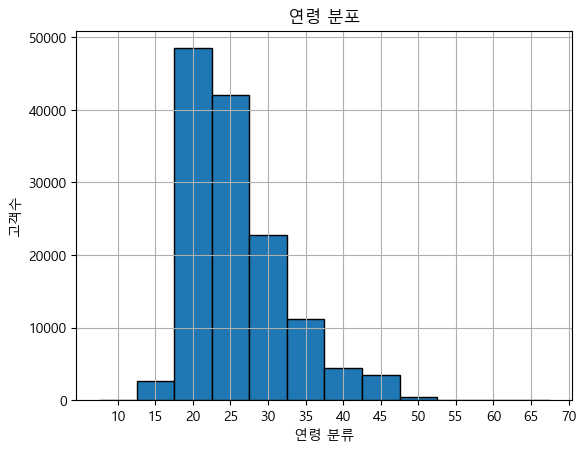

In [83]:
# 20~30대가 주요 고객이며, 핵심 타겟대상
# 연령이 낮을 수록 탈퇴율이 높다는 것은 당연한 결과는 아니다. 
# 일부 서비스에 불만이 있을 수 있으나 탈퇴는 다시 방문하지 않겠다는 강력한 의사표시로서 
# 향후 트렌드의 변화에 따라 재방문 가능성이 높은 아웃소싱의 특성상 연령이 낮은 고객의 탈퇴는 명백한 불만의사표시

import matplotlib.pyplot as plt

# Define bins explicitly (e.g., by decades)
bins = list(range(10, 71, 5))

# Create histogram
plt.hist(df['연령'], bins=bins, edgecolor='black', align='left')
plt.title('연령 분포')
plt.xlabel('연령 분류')
plt.ylabel('고객수')
plt.xticks(bins)  # Show ticks at bin edges

plt.grid(True)
plt.show()

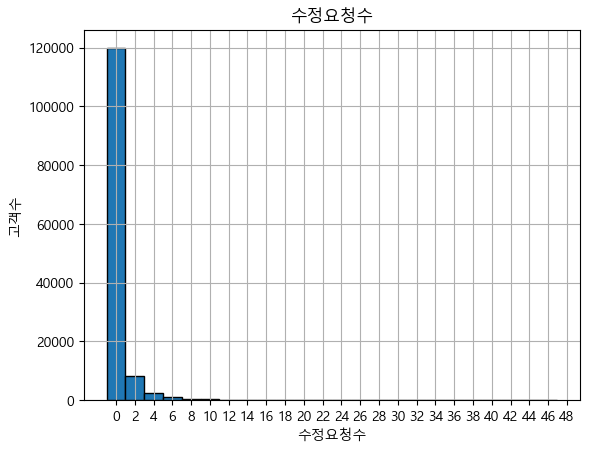

In [85]:
bins = list(range(0, 50, 2))

# Create histogram
plt.hist(df['총수정요청수'], bins=bins, edgecolor='black', align='left')
plt.title('수정요청수')
plt.xlabel('수정요청수')
plt.ylabel('고객수')
plt.xticks(bins)  # Show ticks at bin edges

plt.grid(True)
plt.show()

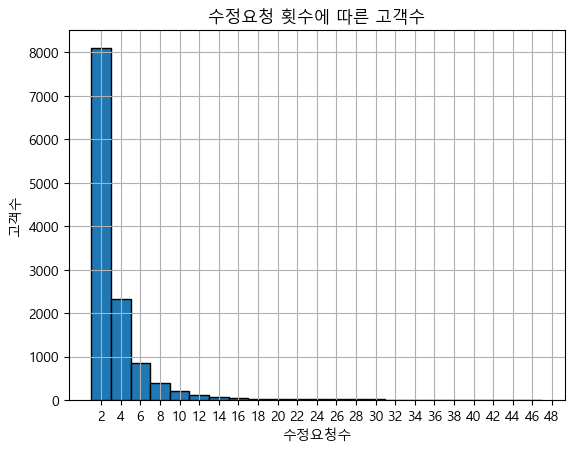

In [87]:
# 0이 압도적으로 수치가 크므로 0과 1을 제외 후 다시 작성
bins = list(range(2, 50, 2))

# Create histogram
plt.hist(df['총수정요청수'], bins=bins, edgecolor='black', align='left')
plt.title('수정요청 횟수에 따른 고객수')
plt.xlabel('수정요청수')
plt.ylabel('고객수')
plt.xticks(bins)  # Show ticks at bin edges

plt.grid(True)
plt.show()

In [77]:
df['총수정요청수'].mean() 
# 대다수의 고객이 수정을 요청하지 않거나 1회에 한하여 요청한다는 의미
# 수정요청수가 많을수록 탈퇴로 예측될 가능성은 높으나, 
# 수정해가는 과정에서 고객의 신뢰도가 올라갈 가능성도 있으므로 수정요청수와 탈퇴가능성은 반드시 비례관계로는 보기 어려우나,
# 우선 데이터분석결과로는 비례로 보여진다. 

0.43456873609353863

In [78]:
df['총수정요청수'].describe()
# 최대 요청수 120
# 최소 요청수 -6으로 구체적인 자료 확인 필요

count    137526.000000
mean          0.434569
std           1.570575
min          -6.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         120.000000
Name: 총수정요청수, dtype: float64

In [79]:
df[df['총수정요청수'] < -1] # -1은 누락값으로 판단한다고 하더라도 -2, -3, -6은 데이터 수집과정 확인 필요

,사용기기,사용OS,유입경로,회원상태,거주지,연령,성별,서비스총구매수,총구매금액,총수정요청수,총추가결제금액
7410,SM,Android7.0,유튜브,0,경기도,28.0,남성,6,126000.0,-2.0,0
9203,SM,Android8.0.0,유튜브,0,충청도,24.0,남성,3,21600.0,-2.0,11600
9216,SM,Android8.0.0,유튜브,0,경상도,25.0,여성,4,173200.0,-2.0,23200
11580,SM,Android8.1.0,NaN,1,경기도,32.0,남성,3,0.0,-3.0,0
11588,iPhone,iOS11.4.1,NaN,0,경상도,24.0,남성,2,0.0,-2.0,1200
...,...,...,...,...,...,...,...,...,...,...,...
116683,SM,Android7.0,유튜브,0,경기도,48.0,남성,9,580350.0,-2.0,11350
118276,LM,Android8.1.0,네이버블로그,0,경기도,21.0,남성,8,135000.0,-2.0,60000
118946,SM,Android7.0,유튜브,0,경상도,31.0,NaN,4,55000.0,-2.0,0
120093,iPhone,iOS11.2.1,네이버블로그,0,경기도,28.0,남성,2,0.0,-2.0,0


In [80]:
df[df['총수정요청수'] > 40] # 현재 모두 정상회원

,사용기기,사용OS,유입경로,회원상태,거주지,연령,성별,서비스총구매수,총구매금액,총수정요청수,총추가결제금액
952,SM,Android6.0.1,유튜브,0,경기도,24.0,남성,77,6071900.0,46.0,198900
62564,LG,Android8.0.0,유튜브,0,경상도,20.0,남성,9,775200.0,120.0,68200
107606,iPhone,iOS11.4,직접검색,0,경상도,27.0,남성,4,475200.0,44.0,149200


In [81]:
# X_numeric = X_test[["연령", "총수정요청수"]].copy()
# explainer = shap.TreeExplainer(model)
# interaction_values = explainer.shap_interaction_values(X_numeric)
# 모든 조합에 대해 연산을 수행하여 오래걸리므로 연령별, 수정요청수별 세분화하여 분석필요

C:\Users\User\AppData\Local\Temp\ipykernel_17580\2417187664.py:44: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = result_df.pivot_table(values="interaction", index="age_bin", columns="rev_bin", aggfunc="mean")
C:\Users\User\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


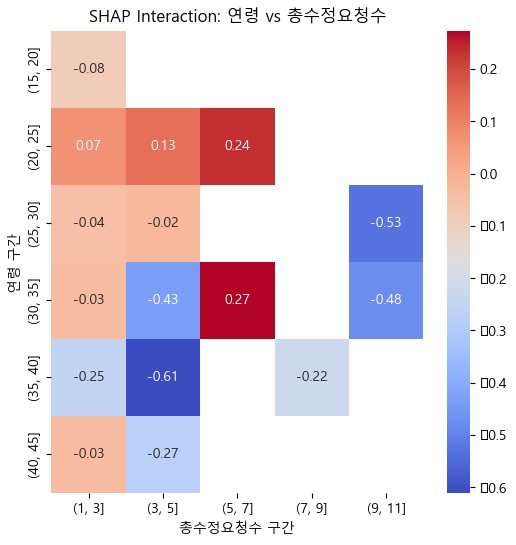

In [88]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# 1. 필요한 컬럼만 선택
df_numeric = df[["연령", "총수정요청수", "회원상태"]].dropna()

# 2. X, y 분리
X = df_numeric[["연령", "총수정요청수"]]
y = df_numeric["회원상태"]  # 탈퇴 여부 (0 또는 1)

# 3. 세분화를 위한 binning (선택사항)
X["연령_bin"] = pd.cut(X["연령"], bins=range(10, 71, 5), right=False)
X["요청수_bin"] = pd.cut(X["총수정요청수"], bins=range(0, 120, 5), right=False)

# 4. 원본 피처만 학습용으로 유지
X_train, X_test, y_train, y_test = train_test_split(X[["연령", "총수정요청수"]], y, test_size=0.2, random_state=42)

# 5. 간단한 모델 학습
model = XGBClassifier()
model.fit(X_train, y_train)

# 6. SHAP interaction value 계산 (샘플 수 줄이기)
X_sample = X_test.head(500)
explainer = shap.TreeExplainer(model)
interaction_values = explainer.shap_interaction_values(X_sample)

# 7. 상호작용 기여도 추출
age_idx = 0
rev_idx = 1
inter_matrix = interaction_values[:, age_idx, rev_idx]

# 8. 시각화를 위한 데이터프레임 구성
result_df = X_sample.copy()
result_df["interaction"] = inter_matrix

# 9. 히트맵 시각화: 연령×수정요청수 구간별 평균 SHAP 기여도
result_df["age_bin"] = pd.cut(result_df["연령"], bins=range(10, 71, 5))
result_df["rev_bin"] = pd.cut(result_df["총수정요청수"], bins=range(1, 40, 2))

pivot = result_df.pivot_table(values="interaction", index="age_bin", columns="rev_bin", aggfunc="mean")

import seaborn as sns
plt.figure(figsize=(6,6))
plt.rcParams['font.family'] = 'Malgun Gothic' 
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("SHAP Interaction: 연령 vs 총수정요청수")
plt.xlabel("총수정요청수 구간")
plt.ylabel("연령 구간")
plt.show()


* 20대 초반과 30대 초반 고객의 경우 수정요청이 5회 이상 넘어가는 시점에서 탈퇴가능성이 높아지므로,
* 수정요청이 5회 다다를 경우 거래에 문제는 없는 지 살필 필요가 있으며,
* 문제가 있을 경우 적극적으로 개입하여 중재시 탈퇴를 방지 할 수 있을 것으로 보인다.
* 수정요청수 5-6회 주변에 있는 3-4회, 7회 이상시 정상회원 가능성이 높아지는 것은 4회 이하의 수정요청에 따라
* 문제가 해결된 경우와 7회 이상의 번번한 수정요청 후 문제가 해결되어 빈번한 요청에도 불구하고 문제가 해결되어
* 고객만족도가 상승한 것으로 추정된다.
* 전반적으로 수정요청수와 정상회원의 기여도를 보면 수정요청 받은 후 적극적인 문제해결 과정이 탈퇴를 방지하는 것으로도 해석된다.
* 판매자들이 구매자들과 보다 밀접하게, 용이하게 접촉할 수 있는 인프라 구성도 바람직해보인다.